In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
%matplotlib inline

In [62]:
df=pd.read_excel(r"c:\Users\H.srinivas\Downloads\enhanced_house_dataset.csv.xlsx")
df

,Area,Bedrooms,Bathrooms,Age,City,Price
0,1260,4,3,24,Pune,1274350
1,5790,2,1,7,Kolkata,1094846
2,5626,5,2,15,Chennai,1495933
3,5591,1,1,47,Delhi,1003442
4,4172,5,1,44,Delhi,1306676
...,...,...,...,...,...,...
1995,4323,1,1,23,Kolkata,768553
1996,4803,4,2,8,Kolkata,1117994
1997,5855,5,2,6,Kolkata,1800277
1998,2369,3,3,15,Chennai,1547695


In [63]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Area       2000 non-null   int64 
 1   Bedrooms   2000 non-null   int64 
 2   Bathrooms  2000 non-null   int64 
 3   Age        2000 non-null   int64 
 4   City       2000 non-null   object
 5   Price      2000 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 93.9+ KB


,Area,Bedrooms,Bathrooms,Age,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,24.008500,1.245014e+06
std,1604.510239,1.427255,0.81263,14.319076,3.001744e+05
min,401.000000,1.000000,1.00000,0.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,12.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,24.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,36.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,49.000000,2.225409e+06


In [64]:
df.shape

(2000, 6)

In [65]:
df.head()

,Area,Bedrooms,Bathrooms,Age,City,Price
0,1260,4,3,24,Pune,1274350
1,5790,2,1,7,Kolkata,1094846
2,5626,5,2,15,Chennai,1495933
3,5591,1,1,47,Delhi,1003442
4,4172,5,1,44,Delhi,1306676


In [66]:
df.tail()

,Area,Bedrooms,Bathrooms,Age,City,Price
1995,4323,1,1,23,Kolkata,768553
1996,4803,4,2,8,Kolkata,1117994
1997,5855,5,2,6,Kolkata,1800277
1998,2369,3,3,15,Chennai,1547695
1999,3193,5,2,18,Pune,1286827


In [67]:
df.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Age          0
City         0
Price        0
dtype: int64

In [68]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1995    False
1996    False
1997    False
1998    False
1999    False
Length: 2000, dtype: bool

Text(0, 0.5, 'Frequency')

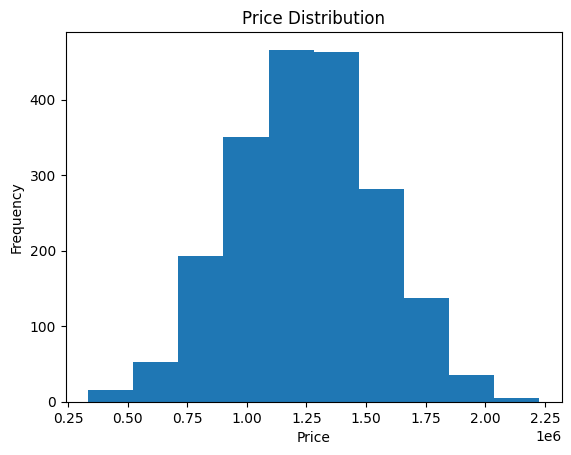

In [69]:
plt.hist(df['Price'])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

Text(0.5, 1.0, 'Area vs Price')

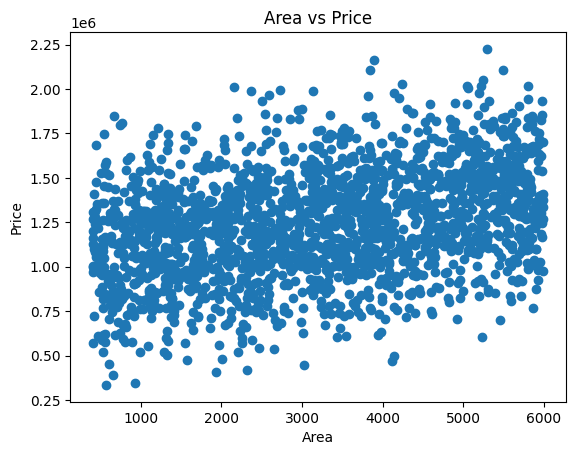

In [70]:
plt.scatter(df['Area'], df['Price'])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")  

Text(0.5, 1.0, 'Correlation Heatmap')

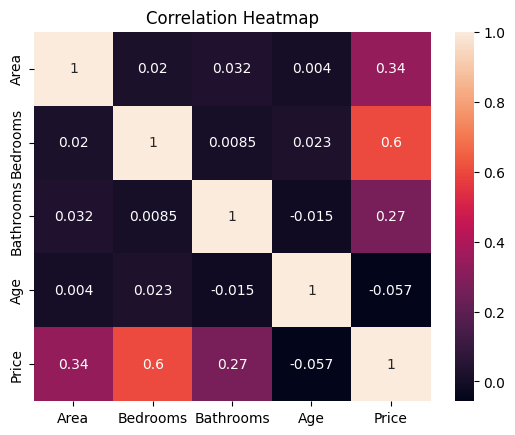

In [71]:

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")

Text(0.5, 1.0, 'Price Outliers')

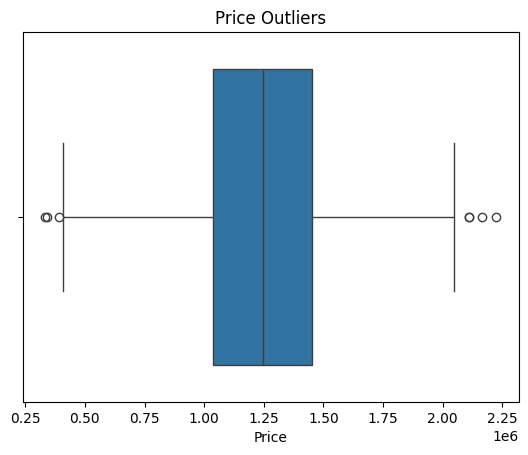

In [72]:
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")

In [73]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'City', 'Price'], dtype='object')

In [74]:
df.columns=df.columns.str.strip()

In [75]:
X = df[['Area', 'Bedrooms', 'Bathrooms', 'Age', 'City']]
y = df['Price']

In [76]:
X = pd.get_dummies(X)

In [77]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test, y_train, y_test 
  

(      Area  Bedrooms  Bathrooms  Age  City_Bangalore  City_Chennai  \
 968   2019         1          1   15           False          True   
 240   2202         5          3    8           False         False   
 819   4556         3          3    7           False          True   
 692   3179         1          2   41           False         False   
 420   1140         5          3   45           False         False   
 ...    ...       ...        ...  ...             ...           ...   
 1130  2025         3          2   22           False         False   
 1294  2481         2          1   17           False          True   
 860   5021         4          1   38           False         False   
 1459  5192         2          1   31           False         False   
 1126  4612         1          2    4           False         False   
 
       City_Delhi  City_Hyderabad  City_Kolkata  City_Mumbai  City_Pune  
 968        False           False         False        False      False 

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
model=LinearRegression()

In [81]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
predictions=model.predict(X_train)
predictions

array([ 844445.16913711, 1552343.69989594, 1434924.13006426, ...,
       1342733.29927966, 1114261.33768483, 1109066.15805082],
      shape=(1600,))

In [83]:
y_pred = model.predict(X_test)
y_pred


array([ 996186.72843238, 1270230.37450436, 1327358.27810415,
        987251.51044835,  943403.415566  , 1331770.90708147,
       1318884.93672002, 1512999.28244858, 1037935.59826529,
       1628344.00957966, 1206484.90205528, 1300618.61661745,
       1265991.64383401, 1179209.11189803, 1337749.87402331,
       1054601.80413271, 1058591.55559192, 1634377.84509558,
        850327.02658496, 1437308.29473757, 1182863.00273731,
       1019883.43475327, 1337935.43723971,  974860.90105352,
        957875.45699754,  918717.49837543, 1139650.55884569,
       1101683.31686802, 1416007.23099656, 1157043.78669401,
       1654895.39571238, 1496771.41623258, 1283665.0598691 ,
        992015.3731283 , 1171578.73659506, 1265121.60521568,
        968144.72570954, 1513352.77870279, 1345398.23879598,
       1395123.08736073,  990670.52819398, 1473193.59384912,
       1180520.15173244,  935120.11344191,  941535.34098355,
       1553818.06124662, 1123515.62272536, 1353804.36760832,
       1404085.83229674,

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np  

In [85]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)  

MAE: 149841.60411321986
MSE: 35678100639.05766
RMSE: 188886.47553241515
R2 Score: 0.6063843344637176
